In [1]:
# Cell 1: Setup environment & project folder
!pip install -q imbalanced-learn

import os
os.makedirs('/content/analytics', exist_ok=True)
%cd /content/analytics
print("Current directory:", os.getcwd())

/content/analytics
Current directory: /content/analytics


=== DATA PROFILE ===
Shape: (891, 15)

Missing Percentages:
age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64

 Saved titanic.csv as offline fallback!

Age IQR Outliers: 27
Fare IQR Outliers: 114
Fare Stats -> Mean: 32.10, Median: 14.45, Mode: 8.05


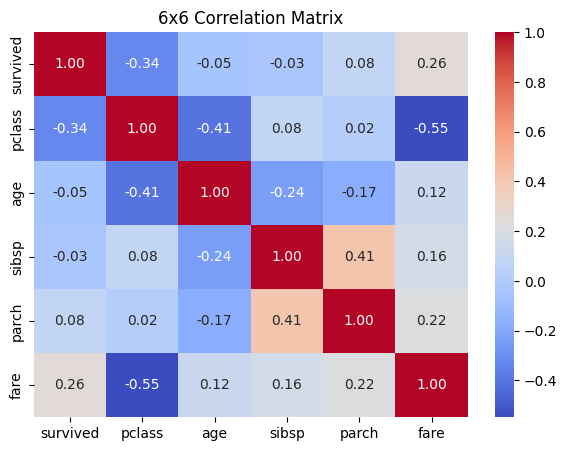

Z-score Check -> Age Mean: 0.00, Std: 1.00
Z-score Check -> Fare Mean: 0.00, Std: 1.00


In [2]:
# Cell 2: Load raw data, profile, clean, save titanic.csv, and produce EDA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load raw dataset ONCE
df = sns.load_dataset('titanic')

print("=== DATA PROFILE ===")
print("Shape:", df.shape)
print("\nMissing Percentages:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].round(2))

# 2. Save committed offline fallback CSV
df.to_csv("titanic.csv", index=False)
print("\n Saved titanic.csv as offline fallback!")

# 3. Apply Threshold Rules
df_clean = df.drop(columns=['deck', 'embark_town']) # >30% missing & redundant
df_clean['age'] = df_clean.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median())) # 5-30%
df_clean = df_clean.dropna(subset=['embarked']) # <5%

# 4. Outliers & Skewness Check
def calc_iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < (q1 - 1.5 * iqr)) | (s > (q3 + 1.5 * iqr))).sum()

print(f"\nAge IQR Outliers: {calc_iqr_outliers(df_clean['age'])}")
print(f"Fare IQR Outliers: {calc_iqr_outliers(df_clean['fare'])}")
print(f"Fare Stats -> Mean: {df_clean['fare'].mean():.2f}, Median: {df_clean['fare'].median():.2f}, Mode: {df_clean['fare'].mode()[0]:.2f}")

# 5. 6x6 Correlation Heatmap
plt.figure(figsize=(7, 5))
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("6x6 Correlation Matrix")
plt.show()

# 6. Exploratory Z-score Standardization Check
scaler = StandardScaler()
scaled_vals = scaler.fit_transform(df_clean[['age', 'fare']])
print(f"Z-score Check -> Age Mean: {scaled_vals[:,0].mean():.2f}, Std: {scaled_vals[:,0].std():.2f}")
print(f"Z-score Check -> Fare Mean: {scaled_vals[:,1].mean():.2f}, Std: {scaled_vals[:,1].std():.2f}")

In [3]:
# Cell 3: Predictive modeling pipeline, imbalance check, tuning, regression, and joblib export
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score

# 1. Read ONLY from committed CSV
data = pd.read_csv("titanic.csv")

X = data.drop(columns=['survived', 'alive', 'deck', 'embark_town'], errors='ignore')
y = data['survived']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing Pipeline
num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['sex', 'embarked', 'pclass']

num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_transformer, num_features), ('cat', cat_transformer, cat_features)])

# Hyperparameter Tuning with OOB Score
rf_base = RandomForestClassifier(oob_score=True, random_state=42)
pipeline_grid = Pipeline([('preprocessor', preprocessor), ('classifier', rf_base)])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 8, None]
}

grid = GridSearchCV(pipeline_grid, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
best_rf = best_pipeline.named_steps['classifier']

print("=== BEST CLASSIFIER RESULTS ===")
print("Best Params:", grid.best_params_)
print(f"OOB Score: {best_rf.oob_score_:.4f}")

# Predict & Evaluate
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")

# 2. Save complete end-to-end pipeline artifact
joblib.dump(best_pipeline, "full_pipeline.joblib")
print("\n Pipeline artifact saved as full_pipeline.joblib!")

# 3. Reload and test verification
loaded_pipe = joblib.load("full_pipeline.joblib")
sample = pd.DataFrame([{'pclass': 3, 'sex': 'male', 'age': 22.0, 'sibsp': 1, 'parch': 0, 'fare': 7.25, 'embarked': 'S'}])
print(" Verification Prediction on Raw Sample:", loaded_pipe.predict(sample)[0])

=== BEST CLASSIFIER RESULTS ===
Best Params: {'classifier__max_depth': 8, 'classifier__n_estimators': 100}
OOB Score: 0.8244
Test Accuracy: 0.8045
Test F1 Score: 0.7200
Test ROC-AUC:  0.8412

 Pipeline artifact saved as full_pipeline.joblib!
 Verification Prediction on Raw Sample: 0


In [4]:
# Cell 4: Verify generated files and download directly
from google.colab import files

print("Generated Artifacts in /analytics:")
print(os.listdir('.'))

# Download submission artifacts directly to your PC
files.download("titanic.csv")
files.download("full_pipeline.joblib")

Generated Artifacts in /analytics:
['full_pipeline.joblib', 'titanic.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>